In [182]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import WeightedRandomSampler

from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report, matthews_corrcoef,
							accuracy_score, precision_score, recall_score, f1_score)

In [183]:
import random
# setting seed so the results are consistently reproducible
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [184]:
train=pd.read_csv("./data/preprocessedTrain.csv")
test=pd.read_csv("./data/preprocessedTest.csv")

In [185]:
# To fill nulls
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1)

In [186]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())

Train shape: (98493, 84)
Test shape: (24624, 84)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

# Multi-Class Classification Model

In [187]:
# Multi class classification
label_encoder = LabelEncoder().fit(train["Attack_type"])

y_train = label_encoder.transform(train["Attack_type"])
y_test = label_encoder.transform(test["Attack_type"])

# Get class names for later
class_names = label_encoder.classes_
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

X_train = train.drop("Attack_type", axis=1)
X_test = test.drop("Attack_type", axis=1).values

Number of classes: 12
Classes: ['ARP_poisioning' 'DDOS_Slowloris' 'DOS_SYN_Hping' 'MQTT_Publish'
 'Metasploit_Brute_Force_SSH' 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION'
 'NMAP_TCP_scan' 'NMAP_UDP_SCAN' 'NMAP_XMAS_TREE_SCAN' 'Thing_Speak'
 'Wipro_bulb']


In [188]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [189]:
values, counts = np.unique(y_train, return_counts=True)
print(values)  
print(counts) 

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[ 4960   342 60581  2653    24    18  1280   642  1657  1286  5189   162]


In [190]:
# put the ports back to one col.
mapping = {
    (1,0): 'icmp',
    (0,1): 'tcp',
    (0,0): 'udp'
}

X_train['port'] = list(zip(X_train.proto_icmp, X_train.proto_tcp))
X_train['port'] = X_train['port'].map(mapping)
X_train = X_train.drop(['proto_icmp','proto_tcp'],axis=1)
X_train

,id.orig_p,id.resp_p,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,f_Header_b_payload_Ratio,b_Header_f_payload_Ratio,bwd_payload_zero_flg,fwd_payload_zero_flg,port
30027,0.921660,0.028797,0.555556,2.025766e-03,0.002536,0.002518,0.000845,0.001709,2.258329e-07,1.254625e-07,...,0.119426,0.0,0.980240,0.409659,0.007660,0.795699,0.169568,0.0,0.0,tcp
29591,0.056260,0.000321,0.000000,2.132037e-10,0.000282,0.000504,0.000282,0.000000,2.352941e-01,2.352941e-01,...,0.000000,0.0,0.000977,0.000000,0.000977,2.000000,0.012785,1.0,0.0,tcp
3174,0.193973,0.000321,0.000000,5.330092e-11,0.000282,0.000504,0.000282,0.000000,1.000000e+00,1.000000e+00,...,0.000000,0.0,0.000977,0.000000,0.000977,2.000000,0.012785,1.0,0.0,tcp
67742,0.837034,0.000321,0.000000,1.066018e-10,0.000282,0.000504,0.000282,0.000000,4.444444e-01,4.444444e-01,...,0.000000,0.0,0.000977,0.000000,0.000977,2.000000,0.012785,1.0,0.0,tcp
32977,0.410147,0.000321,0.000000,2.132037e-10,0.000282,0.000504,0.000282,0.000000,2.352941e-01,2.352941e-01,...,0.000000,0.0,0.000977,0.000000,0.000977,2.000000,0.012785,1.0,0.0,tcp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65681,0.813504,0.028797,0.555556,3.205069e-03,0.002818,0.003021,0.000845,0.002279,1.585979e-07,9.515858e-08,...,0.192681,0.0,0.980240,0.409659,0.007660,0.783751,0.196691,0.0,0.0,tcp
38702,0.866728,0.000321,0.000000,1.066018e-10,0.000282,0.000504,0.000282,0.000000,5.000000e-01,5.000000e-01,...,0.000000,0.0,0.000977,0.000000,0.000977,2.000000,0.012785,1.0,0.0,tcp
76266,0.538201,0.000321,0.000000,2.132037e-10,0.000282,0.000504,0.000282,0.000000,2.500000e-01,2.500000e-01,...,0.000000,0.0,0.000977,0.000000,0.000977,2.000000,0.012785,1.0,0.0,tcp
73974,0.901579,0.000811,0.222222,9.114458e-09,0.000564,0.001007,0.000564,0.001140,1.114206e-02,1.114206e-02,...,0.000000,0.0,0.000000,0.000000,0.000000,0.012984,0.013637,0.0,0.0,udp


In [191]:
smote = SMOTENC(random_state=42,categorical_features=[2,81],sampling_strategy={0: np.rint(4960*1.2,).astype(int),
                                                                            1: np.rint(342*2).astype(int),
                                                                            2: np.rint(60581).astype(int),
                                                                            3: np.rint(2653*1.5).astype(int),
                                                                            4: np.rint(24*3).astype(int),
                                                                            5: np.rint(18*3).astype(int),
                                                                            6: np.rint(1280*1.75).astype(int),
                                                                            7: np.rint(642*2).astype(int),
                                                                            8: np.rint(1657*1.5).astype(int),
                                                                            9: np.rint(1286*1.75).astype(int),
                                                                            10: np.rint(5189*1.2).astype(int),
                                                                            11: np.rint(162*2).astype(int)})
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [192]:
X_train_res = pd.get_dummies(X_train_res)
X_train_res = X_train_res.drop(['port_udp'],axis=1)

In [193]:
X_train_res = X_train_res.values
X_train_res = X_train_res.astype(np.float32)

In [194]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.long) 

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long) 

# Validation
X_val=X_val.values
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long) 

In [195]:
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)
X_val_tensor = X_val_tensor.unsqueeze(1)

In [196]:
y = np.array(y_train_res)
class_counts = np.bincount(y)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights),replacement=True)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)



train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)

In [197]:

class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.class_weights = class_weights
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none', weight=self.class_weights)
        pt = torch.exp(-ce)  
        loss = (1 - pt) ** self.gamma * ce

        if self.reduction == 'mean':
            return loss.mean()
        return loss


In [126]:
x = next(iter(train_loader))
print(X_train_tensor.shape, X_test_tensor.shape)

torch.Size([107666, 1, 83]) torch.Size([24624, 1, 83])


In [198]:
# input data format (batch_size, sequence_length, num_features)
# (batch, 1, 83) 
# the sequence represents temporal ordering...this would exist in real-time situation
class MultiClass1dCNN(nn.Module):
    def __init__(self, num_features=83, num_classes=12, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.conv1 = nn.Conv1d(in_channels=1,out_channels=16,kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(in_channels=16,out_channels=32,kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(32)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(32)
        self.pool = nn.AvgPool1d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*(num_features//2),256)
        self.fc2 = nn.Linear(256,128)
        self.dropout = nn.Dropout1d(.3)
        self.fc3 = nn.Linear(128,num_classes)

    def forward(self,x):
        # convolutions
        x = F.relu(self.bn3(self.conv3(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x)))))))))
        x = self.pool(x)
        # dense layers
        x = self.fc3(F.relu(self.fc2(self.dropout(F.relu(self.fc1(self.flatten(x)))))))
        # output
        return x

In [199]:
# Check if gpu is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


model = MultiClass1dCNN()
model = model.to(device) 
criterion=FocalLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Using device: cpu


In [200]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_loss = 0.0
    print("start epcoh")

    for batch, (X_batch, y_batch) in enumerate(train_loader):
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        total_loss+=loss.item()

        if (batch+1) % 500 == 0:
            print(f"[{epoch+1}, {batch+1}] loss: {running_loss/500:.4f}")
            running_loss = 0.0


    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}")

start epcoh
[1, 500] loss: 0.9071
[1, 1000] loss: 0.6749
Epoch [1/3], Avg Loss: 0.7583
start epcoh
[2, 500] loss: 0.6681
[2, 1000] loss: 0.6691
Epoch [2/3], Avg Loss: 0.6654
start epcoh
[3, 500] loss: 0.6505
[3, 1000] loss: 0.6428
Epoch [3/3], Avg Loss: 0.6446


In [130]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))

[[ 1462     1     0     4    12     6     0     0    41     0    22     2]
 [    0   106     0     0     1     0     0     0     0     0     0     0]
 [   72     0 18860     0     0     0     0     0     0     0     0     0]
 [    2     0     0   824     0     0     0     0     3     0     0     0]
 [    0     0     0     0     7     0     0     0     0     0     0     0]
 [    1     0     0     0     0     0     0     0     5     0     0     0]
 [    0     0     0     0     0     0     0     0   400     0     0     0]
 [    0     0     0     0     0     0     0     0   200     0     0     0]
 [    2    24     0     0     3    36     0     0   452     0     1     0]
 [    1     0     0     0     0     1     0     0   400     0     0     0]
 [  547     2     0     0   236     1     0     0     2     0   833     1]
 [   12     0     0     0     0     1     0     0     7     0     0    31]]
                            precision    recall  f1-score   support

            ARP_poisioning    

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [ ]:
model.eval()
all_preds = []
all_labels = []


with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))


[[ 1492     1     0     0     8     0     0     0     0     0     8    41]
 [   30    56     0     0     1     0     0     0    20     0     0     0]
 [    0     0 18032     0     0   682     0     0     0     0     0   218]
 [    1     0     0   825     0     0     0     0     0     0     0     3]
 [    0     0     0     0     7     0     0     0     0     0     0     0]
 [    0     0     0     0     1     0     0     0     0     0     0     5]
 [    0     0     0     0     0     0     0     0     0     0     0   400]
 [    0     0     0     0     0     0     0     0     0     0     0   200]
 [    1     0     0     0     4    25     0     0   160     0    24   304]
 [    0     0     0     0     2     0     0     0     0     0     0   400]
 [  279     0     0     1     0     0     0     0     1     0  1328    13]
 [    0     0     0     0     0     0     0     0     0     0     0    51]]
                            precision    recall  f1-score   support

            ARP_poisioning    

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [ ]:
# Convert to DataFrame and save as CSV
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_reports/evaluation_metrics_1d_cnn_multi.csv", index=True)
print("Success")

In [ ]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
precw = precision_score(all_labels, all_preds, average='weighted')
recw = recall_score(all_labels, all_preds, average='weighted')
f1w = f1_score(all_labels, all_preds, average='weighted')
mcc = matthews_corrcoef(all_labels, all_preds)


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"\nOverall Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall: {rec:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print(f"Macro Precision: {precw:.4f}")
print(f"Macro Recall: {recw:.4f}")
print(f"Macro F1 Score: {f1w:.4f}")
print(f"MCC Score: {mcc:.4f}")


Classification Report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.07      0.77      0.13      1550
            DDOS_Slowloris       1.00      0.02      0.04       107
             DOS_SYN_Hping       1.00      0.03      0.05     18932
              MQTT_Publish       1.00      0.02      0.04       829
Metasploit_Brute_Force_SSH       0.00      0.00      0.00         7
             NMAP_FIN_SCAN       0.00      0.00      0.00         6
         NMAP_OS_DETECTION       0.00      0.00      0.00       400
             NMAP_TCP_scan       0.01      0.17      0.01       200
             NMAP_UDP_SCAN       1.00      0.01      0.02       518
       NMAP_XMAS_TREE_SCAN       0.00      0.00      0.00       402
               Thing_Speak       0.02      0.02      0.02      1622
                Wipro_bulb       0.01      0.10      0.01        51

                  accuracy                           0.07     24624
                 macro

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

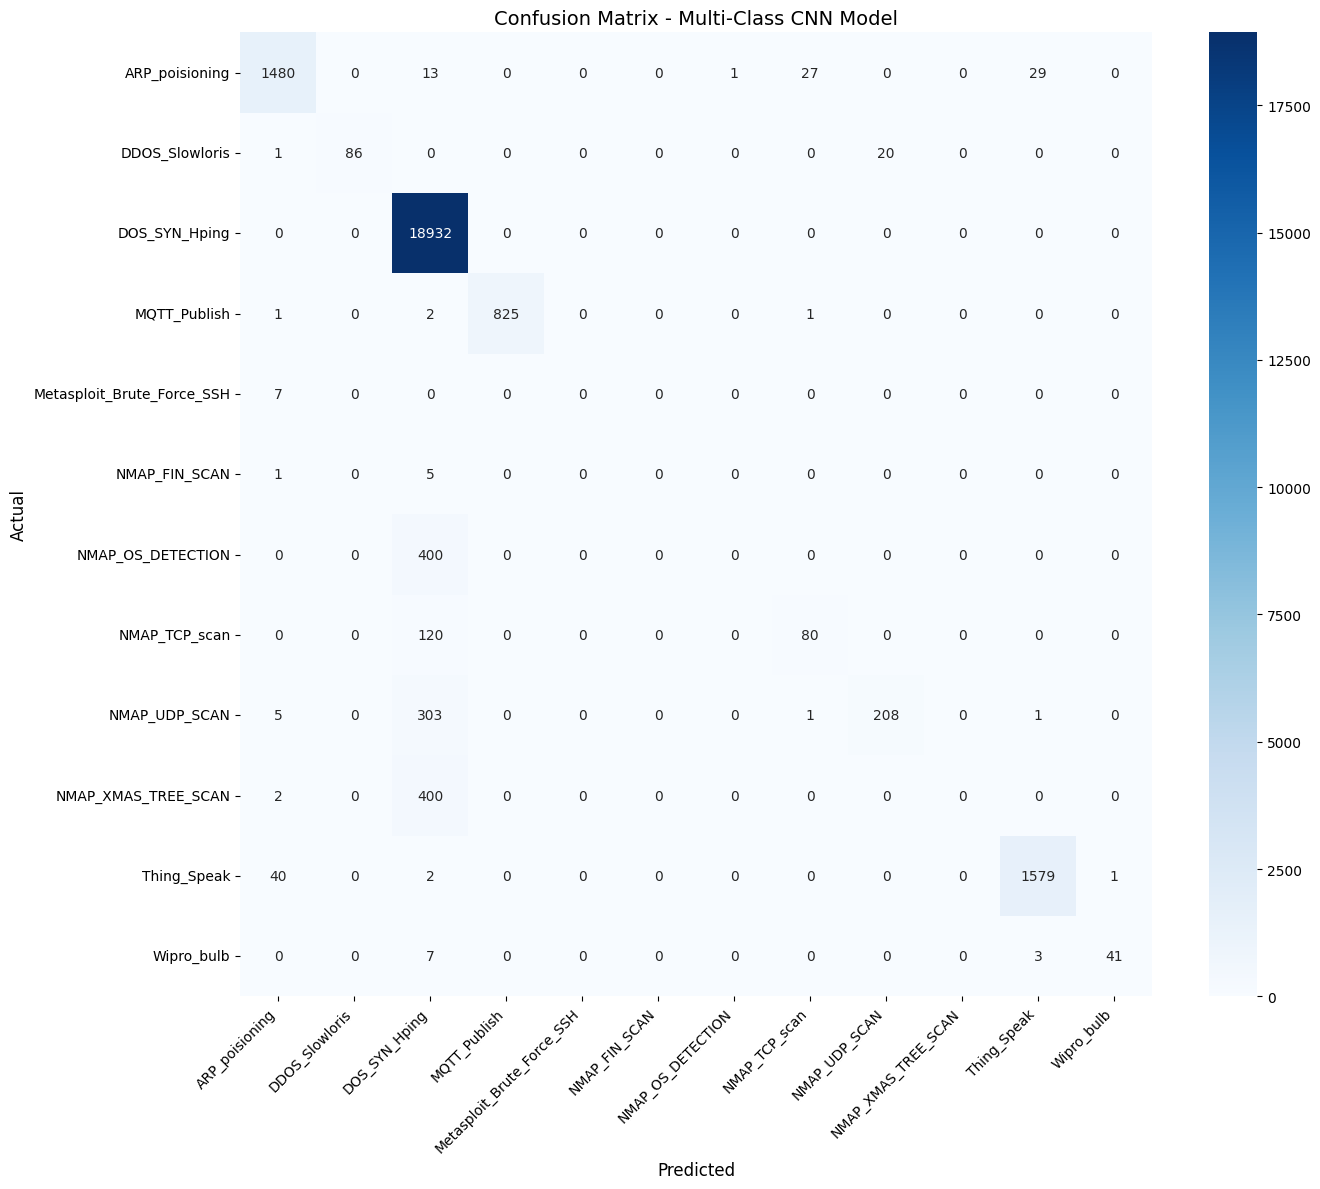

<Figure size 640x480 with 0 Axes>

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - Multi-Class CNN Model", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig("confusionmatrices/1dcnn_multi.png", dpi=600, bbox_inches='tight')

In [ ]:
torch.save(model.state_dict(), "models/1dcnn_multiclass.pth")
print("Model saved to models/1dcnn_multiclass.pth")

Model saved to models/1dcnn_multiclass.pth
